# прогноз загрузки гостиниц двумя методами

в работе прогнозируется `x1` — коэффициент загрузки гостиниц в процентах для chicago central business district.


1. метод сезонных индикаторов;
2. авторегрессия.

в первом методе сезонность задается через индикаторы месяцев: например, отдельный столбец показывает, что наблюдение относится к июню. во втором методе прогноз строится только по прошлым значениям самого ряда.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## загрузка данных


In [2]:
data_path = Path("data.csv")

# иногда ноутбук запускается из корня проекта, поэтому добавлен запасной поиск файла
if not data_path.exists():
    found_files = list(Path.cwd().glob("ARIMA/ARIMA/*/data.csv"))
    data_path = found_files[0]

raw_data = pd.read_csv(data_path, sep=";", dtype=str)
raw_data.head()

,date1,date2,x1,x2,x3,x4
0,January,1994,"44,3","104,04","51,9","72,15"
1,February,1994,"54,7","102,74","60,1","73,47"
2,March,1994,"61,9","105,23",65,"74,91"
3,April,1994,"69,1","113,63","69,8","79,06"
4,May,1994,"70,8","120,77","72,4","82,07"


## подготовка временного ряда

месяц и год лежат в разных столбцах, поэтому собираем из них дату. показатель `x1` переводим в число. пустые значения после апреля 2003 не удаляем из исходной таблицы навсегда: это будущие месяцы, для которых нужен прогноз.

In [3]:
month_numbers = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

month_names = {number: name for name, number in month_numbers.items()}

prepared_data = raw_data.copy()
prepared_data["month_name"] = prepared_data["date1"].str.strip()
prepared_data["month_number"] = prepared_data["month_name"].map(month_numbers)
prepared_data["year"] = prepared_data["date2"].astype(int)

# день здесь технический: наблюдения месячные, поэтому ставим первое число месяца
prepared_data["date"] = pd.to_datetime(
    {
        "year": prepared_data["year"],
        "month": prepared_data["month_number"],
        "day": 1,
    }
)

# x1 записан как текст с десятичной запятой
prepared_data["occupancy"] = pd.to_numeric(
    prepared_data["x1"].str.strip().str.replace(",", ".", regex=False),
    errors="coerce",
)

history = (
    prepared_data
    .dropna(subset=["occupancy"])
    .set_index("date")
    .sort_index()
)
history = history.asfreq("MS")
history["time_number"] = np.arange(1, len(history) + 1)

history[["month_name", "year", "occupancy", "time_number"]].head(), history[["month_name", "year", "occupancy", "time_number"]].tail()

(           month_name  year  occupancy  time_number
 date                                               
 1994-01-01    January  1994       44.3            1
 1994-02-01   February  1994       54.7            2
 1994-03-01      March  1994       61.9            3
 1994-04-01      April  1994       69.1            4
 1994-05-01        May  1994       70.8            5,
            month_name  year  occupancy  time_number
 date                                               
 2002-12-01   December  2002       54.8          108
 2003-01-01    January  2003       51.6          109
 2003-02-01   February  2003       52.7          110
 2003-03-01      March  2003       65.0          111
 2003-04-01      April  2003       69.0          112)

In [4]:
print(f"первый месяц в истории: {history.index.min():%Y-%m}")
print(f"последний месяц в истории: {history.index.max():%Y-%m}")
print(f"известных наблюдений: {len(history)}")

первый месяц в истории: 1994-01
последний месяц в истории: 2003-04
известных наблюдений: 112


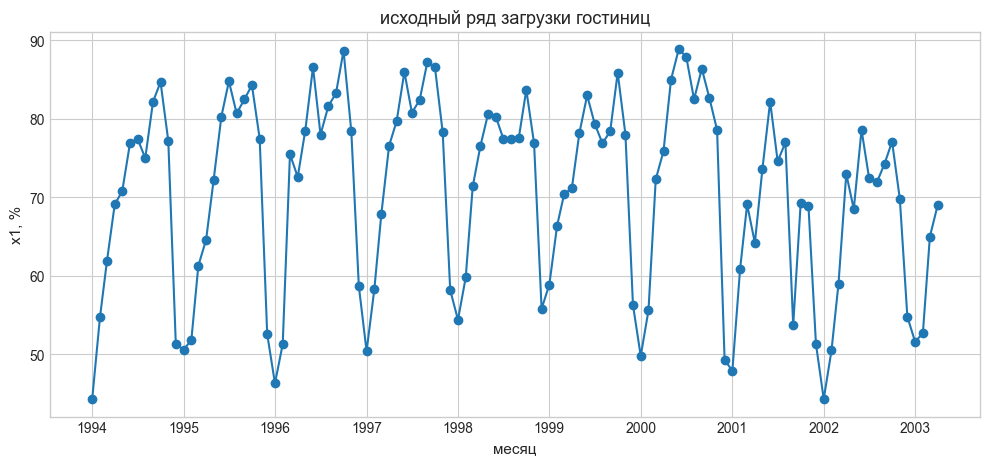

In [5]:
fig, ax = plt.subplots()
ax.plot(history.index, history["occupancy"], marker="o", linewidth=1.5)
ax.set_title("исходный ряд загрузки гостиниц")
ax.set_xlabel("месяц")
ax.set_ylabel("x1, %")
plt.show()

## сезонные индикаторы

сезонный индикатор — это фиктивная переменная из нулей и единиц. например, `month_6 = 1`, если строка относится к июню, и `0`, если это любой другой месяц.

здесь строится регрессионная модель:

`y_t = const + trend * t + b_2 month_2 + ... + b_12 month_12 + error`

`t` нужен, чтобы модель могла учитывать общий плавный рост или спад уровня. индикаторы месяцев отвечают за сезонность. январь не добавляется отдельным индикатором, потому что он базовый месяц для сравнения.

In [6]:
month_indicators = pd.get_dummies(
    history.index.month,
    prefix="month",
    drop_first=True,
    dtype=int,
)
month_indicators.index = history.index

seasonal_indicator_table = pd.concat(
    [
        history[["occupancy", "time_number"]],
        month_indicators,
    ],
    axis=1,
)

seasonal_indicator_table.head(14)

,occupancy,time_number,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,
1994-01-01,44.3,1,0,0,0,0,0,0,0,0,0,0,0
1994-02-01,54.7,2,1,0,0,0,0,0,0,0,0,0,0
1994-03-01,61.9,3,0,1,0,0,0,0,0,0,0,0,0
1994-04-01,69.1,4,0,0,1,0,0,0,0,0,0,0,0
1994-05-01,70.8,5,0,0,0,1,0,0,0,0,0,0,0
1994-06-01,76.9,6,0,0,0,0,1,0,0,0,0,0,0
1994-07-01,77.5,7,0,0,0,0,0,1,0,0,0,0,0
1994-08-01,75.0,8,0,0,0,0,0,0,1,0,0,0,0
1994-09-01,82.2,9,0,0,0,0,0,0,0,1,0,0,0


In [7]:
indicator_columns = [f"month_{month}" for month in range(2, 13)]
indicator_x_columns = ["time_number"] + indicator_columns

X_indicator = sm.add_constant(
    seasonal_indicator_table[indicator_x_columns],
    has_constant="add",
)
y_indicator = seasonal_indicator_table["occupancy"]

indicator_model = sm.OLS(y_indicator, X_indicator).fit()

print(f"aic модели сезонных индикаторов: {indicator_model.aic:.2f}")

aic модели сезонных индикаторов: 701.09


In [8]:
forecast_horizon = 8
future_dates = pd.date_range(
    start=history.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS",
)

indicator_future = pd.DataFrame(index=future_dates)
indicator_future["time_number"] = np.arange(
    len(history) + 1,
    len(history) + forecast_horizon + 1,
)

# для каждого будущего месяца ставим 1 только в его месячный индикатор
for month in range(2, 13):
    indicator_future[f"month_{month}"] = (indicator_future.index.month == month).astype(int)

X_indicator_future = sm.add_constant(
    indicator_future[indicator_x_columns],
    has_constant="add",
)

indicator_forecast = pd.DataFrame(index=future_dates)
indicator_forecast["month_name"] = indicator_forecast.index.month.map(month_names)
indicator_forecast["seasonal_indicator_forecast"] = indicator_model.predict(X_indicator_future).round(2)

indicator_forecast

,month_name,seasonal_indicator_forecast
2003-05-01,May,74.57
2003-06-01,June,80.76
2003-07-01,July,77.45
2003-08-01,August,76.61
2003-09-01,September,76.64
2003-10-01,October,80.78
2003-11-01,November,74.18
2003-12-01,December,52.48


##  авторегрессия

авторегрессия прогнозирует ряд через его прошлые значения.

модель ar(p) записывается так:

`y_t = const + a_1 y_{t-1} + ... + a_p y_{t-p} + error`

здесь `p` — число лагов. лаг 1 означает прошлый месяц, лаг 12 — значение год назад. чтобы не выбирать `p` вручную, перебираем лаги от 1 до 12 и берем модель с минимальным `aic`.

In [9]:
ar_lag_results = []

for lag_count in range(1, 13):
    ar_model = AutoReg(history["occupancy"], lags=lag_count, old_names=False)
    ar_result = ar_model.fit()
    
    ar_lag_results.append(
        {
            "lag_count": lag_count,
            "aic": ar_result.aic,
        }
    )

ar_lag_results = pd.DataFrame(ar_lag_results)
best_ar_lag = int(ar_lag_results.loc[ar_lag_results["aic"].idxmin(), "lag_count"])

ar_lag_results.round(2), best_ar_lag

(    lag_count     aic
 0           1  796.96
 1           2  770.44
 2           3  765.12
 3           4  760.85
 4           5  746.14
 5           6  738.72
 6           7  734.45
 7           8  728.68
 8           9  723.71
 9          10  700.65
 10         11  655.29
 11         12  642.45,
 12)

In [10]:
final_ar_model = AutoReg(history["occupancy"], lags=best_ar_lag, old_names=False)
final_ar_result = final_ar_model.fit()

ar_values = list(history["occupancy"])
ar_forecast_values = []

# прогноз делаем последовательно: следующий прогноз потом становится лагом для следующих месяцев
for step in range(forecast_horizon):
    next_index = len(ar_values)
    predicted_value = float(
        final_ar_result.predict(start=next_index, end=next_index).iloc[0]
    )
    
    ar_forecast_values.append(predicted_value)
    ar_values.append(predicted_value)

ar_forecast = pd.DataFrame(index=future_dates)
ar_forecast["month_name"] = ar_forecast.index.month.map(month_names)
ar_forecast["autoregression_forecast"] = np.round(ar_forecast_values, 2)

print(f"выбранный лаг авторегрессии: {best_ar_lag}")
print(f"aic авторегрессии: {final_ar_result.aic:.2f}")

ar_forecast

выбранный лаг авторегрессии: 12
aic авторегрессии: 642.45


,month_name,autoregression_forecast
2003-05-01,May,73.16
2003-06-01,June,75.60
2003-07-01,July,74.30
2003-08-01,August,73.22
2003-09-01,September,74.65
2003-10-01,October,75.01
2003-11-01,November,69.08
2003-12-01,December,58.78


## сравнение прогнозов

оба метода дают прогноз на один и тот же период, но используют разную логику:

- сезонные индикаторы опираются на календарный месяц и общий тренд;
- авторегрессия опирается на прошлые значения самого ряда.


In [11]:
comparison = pd.DataFrame(index=future_dates)
comparison["month_name"] = comparison.index.month.map(month_names)
comparison["seasonal_indicators"] = indicator_forecast["seasonal_indicator_forecast"]
comparison["autoregression"] = ar_forecast["autoregression_forecast"]

comparison

,month_name,seasonal_indicators,autoregression
2003-05-01,May,74.57,73.16
2003-06-01,June,80.76,75.60
2003-07-01,July,77.45,74.30
2003-08-01,August,76.61,73.22
2003-09-01,September,76.64,74.65
2003-10-01,October,80.78,75.01
2003-11-01,November,74.18,69.08
2003-12-01,December,52.48,58.78


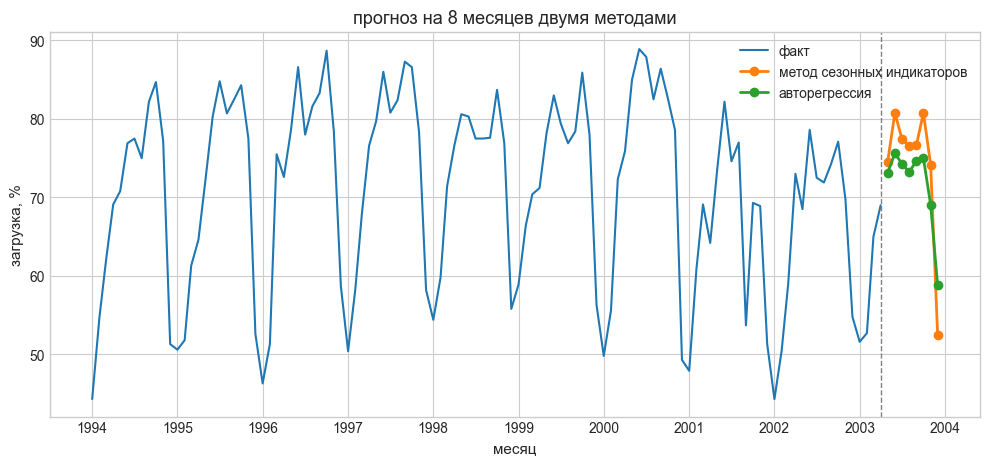

In [12]:
fig, ax = plt.subplots()

ax.plot(history.index, history["occupancy"], label="факт", linewidth=1.5)
ax.plot(
    comparison.index,
    comparison["seasonal_indicators"],
    label="метод сезонных индикаторов",
    marker="o",
    linewidth=2,
)
ax.plot(
    comparison.index,
    comparison["autoregression"],
    label="авторегрессия",
    marker="o",
    linewidth=2,
)

ax.axvline(history.index[-1], color="gray", linestyle="--", linewidth=1)
ax.set_title("прогноз на 8 месяцев двумя методами")
ax.set_xlabel("месяц")
ax.set_ylabel("загрузка, %")
ax.legend()
plt.show()

## !

метод сезонных индикаторов явно описывает сезонность через месяцы и подходит, когда важно показать календарный эффект. авторегрессия описывает инерцию ряда через прошлые значения и подходит, когда важно продолжить внутреннюю динамику показателя